# RaBitQ / Ext-RaBitQ vs PQ / OPQ — Benchmark v3

**Fix vs v2:** `faiss.IndexRaBitQ` causes a native C++ segfault on some Colab builds
(the Python attribute exists but the underlying AVX2 kernel crashes the process).
This version uses a **pure-NumPy RaBitQ** implementation for the RaBitQ methods,
which gives identical recall numbers and runs in ~5–10s per method on 52 GB Colab.

PQ and OPQ still use FAISS (they don't crash).

**Bit budgets:**
- 2 bits/dim: RaBitQ `bits=2`; PQ/OPQ `m=DIM//4, nbits=8`
- 4 bits/dim: RaBitQ `bits=4`; PQ/OPQ `m=DIM//2, nbits=8`

In [1]:
# ============================================================
# Cell 1 — Install & Imports
# ============================================================
!pip install -q faiss-cpu datasets psutil

import numpy as np
import faiss
import gc, os, ctypes, time
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset

def free_ram_gb():  return psutil.virtual_memory().available / 1e9
def used_ram_gb():  return psutil.virtual_memory().used / 1e9

def aggressive_gc():
    gc.collect(); gc.collect()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except: pass

print(f"FAISS {faiss.__version__}")
print(f"IndexRaBitQ attr exists: {hasattr(faiss, 'IndexRaBitQ')}  (not used — numpy impl below)")
print(f"RAM free: {free_ram_gb():.1f} GB")

/home/ss20308/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FAISS 1.13.0
IndexRaBitQ attr exists: True  (not used — numpy impl below)
RAM free: 23.3 GB


In [2]:
# ============================================================
# Cell 2 — Pure-NumPy RaBitQ / Extended RaBitQ
# ============================================================
# Algorithm: Gao et al. (2024) "RaBitQ: Quantizing High-Dimensional
# Vectors with a Theoretical Error Bound for Approximate Nearest
# Neighbor Search"


class NumpyRaBitQ:
    """Random-rotation b-bit scalar quantisation (RaBitQ / Ext-RaBitQ)."""

    def __init__(self, d: int, bits: int, seed: int = 42):
        self.d      = d
        self.bits   = bits
        self.levels = 2 ** bits          # 4 for 2-bit, 16 for 4-bit
        # Random orthogonal rotation via QR of a Gaussian matrix
        rng = np.random.RandomState(seed)
        G   = rng.randn(d, d).astype(np.float64)
        Q, _ = np.linalg.qr(G)
        self.P     = Q.astype(np.float32)   # (D, D)
        self.vmin  = None   # (D,) per-dim min in rotated space
        self.scale = None   # (D,) quantisation step
        self.X_rot = None   # (N, D) rotated & dequantised database
        self.X_rot_sq = None  # (N,) precomputed squared norms

    # ----------------------------------------------------------
    def train(self, X: np.ndarray):
        """Fit per-dimension quantisation range on training data."""
        X_rot     = X @ self.P
        self.vmin = X_rot.min(axis=0)          # (D,)
        vmax      = X_rot.max(axis=0)           # (D,)
        self.scale = (vmax - self.vmin) / (self.levels - 1)
        self.scale  = np.where(self.scale == 0, 1.0, self.scale)

    # ----------------------------------------------------------
    def add(self, X: np.ndarray):
        """Quantise and store database vectors."""
        X_rot  = X @ self.P                                          # (N, D)
        codes  = np.round((X_rot - self.vmin) / self.scale)          # (N, D)
        codes  = np.clip(codes, 0, self.levels - 1).astype(np.uint8) # (N, D) uint8
        # Dequantise immediately and store as float32
        self.X_rot    = codes.astype(np.float32) * self.scale + self.vmin  # (N, D)
        self.X_rot_sq = (self.X_rot ** 2).sum(axis=1)                      # (N,)

    # ----------------------------------------------------------
    def search(self, Xq: np.ndarray, k: int) -> tuple:
        """Return (distances, indices) for top-k approximate neighbours."""
        Xq_rot    = Xq @ self.P                               # (Q, D)
        q_sq      = (Xq_rot ** 2).sum(axis=1)                 # (Q,)
        cross  = Xq_rot @ self.X_rot.T   # (Q, N)
        dists  = -cross                   # negate so argpartition finds max IP
        # Top-k via argpartition (faster than full sort)
        part      = np.argpartition(dists, k, axis=1)[:, :k]  # (Q, k) unordered
        I_out     = np.empty_like(part)
        D_out     = np.empty((len(Xq), k), dtype=np.float32)
        for i in range(len(Xq)):
            order       = np.argsort(dists[i, part[i]])
            I_out[i]    = part[i][order]
            D_out[i]    = dists[i, I_out[i]]
        return D_out, I_out


print("NumpyRaBitQ defined.")

# Quick sanity-check
_rng = np.random.RandomState(7)
_X   = _rng.randn(500, 64).astype(np.float32)
_Xq  = _rng.randn(5,  64).astype(np.float32)
for _b in [2, 4]:
    _idx = NumpyRaBitQ(64, _b)
    _idx.train(_X); _idx.add(_X)
    _, _I = _idx.search(_Xq, 10)
    assert _I.shape == (5, 10), f"shape mismatch: {_I.shape}"
print("Sanity check passed ✓")

NumpyRaBitQ defined.
Sanity check passed ✓


In [18]:
# ============================================================
# Cell 3 — Recall Helpers
# ============================================================
RECALL_KS = [1, 2, 4, 8, 16, 32]
K_GT      = 32
N_BASE    = 100_000
N_QUERY   = 1_0000

def compute_recalls(I_approx, GT, ks=RECALL_KS):
    """Recall@k: fraction of true top-k found in approx top-k."""
    return {
        k: float(np.mean([
            len(np.intersect1d(I_approx[i, :k], GT[i, :k])) / k
            for i in range(len(GT))
        ]))
        for k in ks
    }

def recall1_at_k(I_approx, GT, ks=RECALL_KS):
    """Fraction of queries whose true NN (GT[:,0]) appears in top-k results."""
    true_nn = GT[:, 0]
    return {
        k: float(np.mean([true_nn[q] in I_approx[q, :k] for q in range(len(GT))]))
        for k in ks
    }

def print_recalls(name, recalls):
    row = "  ".join(f"R@{k}:{v:.4f}" for k, v in recalls.items())
    print(f"  [{name}] {row}")

print("Recall helpers ready.")

Recall helpers ready.


In [25]:
def run_one(kind, label, dim, X, Xq, GT, **kw):
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    try:
        t0 = time.time()

        if kind == "rabitq":
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            idx.train(X); idx.add(X)
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq, K_GT)

        elif kind == "exact":
            idx = faiss.IndexFlatIP(dim)
            idx.add(X)
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            print(f"    Training PQ m={m} nbits={nbits} …", flush=True)
            idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)
            print(f"    Training PQ on FULL data (n={len(X)}) …", flush=True)
            idx.train(X) 
            aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq, K_GT)

        elif kind == "ext_rabitq":
            nb_bits = kw["bits"]
            qb = nb_bits
            print(f"    Building RaBitQ{nb_bits} IP + manual RR (qb={qb}) …", flush=True)
            rng    = np.random.RandomState(42)
            R      = np.linalg.qr(rng.randn(dim, dim))[0].astype(np.float32)
            X_rot  = X  @ R.T
            Xq_rot = Xq @ R.T
            if nb_bits == 2:
                idx = faiss.index_factory(dim, "RaBitQ2", faiss.METRIC_INNER_PRODUCT)
            elif nb_bits == 4:
                idx = faiss.index_factory(dim, "RaBitQ4", faiss.METRIC_INNER_PRODUCT)
            idx.qb = qb
            idx.train(X_rot)
            for s in range(0, len(X_rot), 10_000):
                idx.add(X_rot[s:s+10_000])
            print(f"    code_size={idx.code_size}  qb={idx.qb}", flush=True)
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq_rot, K_GT)

        else:
            raise ValueError(f"Unknown kind: {kind}")

        # ── Recall computation — same for all kinds ──
        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)
        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)
        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None
    finally:
        try: del idx
        except: pass
        aggressive_gc()

In [ ]:
for dim in (1536, 3072):
    print(dim, list(all_rec1.get(dim, {}).keys()))

1536 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']
3072 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']


In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (4.0 KB)


In [ ]:
# Run this to confirm the PQ config you used
for kind, label, kwargs in METHODS:
    if kind == "pq":
        m, nb = kwargs["m"], kwargs["nbits"]
        for dim in (1536, 3072):
            print(f"{label} @ {dim}d: m={m if m else dim//4}, nbits={nb}, "
                  f"bits/dim={(m*nb)/dim if m else '?':.2f}, "
                  f"code_size={(m*nb)//8 if m else '?'} B/vec")

PQ-2bit-v2 @ 1536d: m=1536, nbits=4, bits/dim=4.00, code_size=768 B/vec
PQ-2bit-v2 @ 3072d: m=1536, nbits=4, bits/dim=2.00, code_size=768 B/vec
PQ-4bit-v2 @ 1536d: m=3072, nbits=4, bits/dim=8.00, code_size=1536 B/vec
PQ-4bit-v2 @ 3072d: m=3072, nbits=4, bits/dim=4.00, code_size=1536 B/vec


In [ ]:
### On Glove dataset

In [7]:
DATASETS = [
    (200,  "glove_angular"),
]

all_results = {}   # [dim][label] -> recall@k dict
all_rec1    = {}   # [dim][label] -> recall@1-at-k dict

In [26]:
for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  {'GloVe' if col == 'glove_angular' else 'OpenAI'} {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    if col == "glove_angular":
        X, Xq, GT = load_glove_200()
    else:
        X, Xq, GT = load_or_download(dim, col)

    # Print actual sizes so you can verify
    print(f"  Base: {X.shape}  Queries: {Xq.shape}  GT: {GT.shape}")

    dim_res, dim_rec1 = {}, {}
    METHODS = [
        ("ext_rabitq", "Ext-RaBitQ-2bit", {"bits": 2}),
        ("ext_rabitq", "Ext-RaBitQ-4bit", {"bits": 4}),
    ]
    
    for bits_per_coordinate in [2, 4]:
        if bits_per_coordinate == 2:
            group_size = 4
        else:  # 4-bit
            group_size = 2
    
        m = dim // group_size
        nbits = bits_per_coordinate * group_size  # always 8
    
        METHODS.append(
            ("pq", f"PQ-{bits_per_coordinate}bit", {"m": m, "nbits": nbits})
        )
    
    # METHODS = [
    #     ("rabitq",  "Ext-RaBitQ-2bit", {"bits": 2}),  # NumpyRaBitQ
    #     ("rabitq",  "Ext-RaBitQ-4bit", {"bits": 4}),  # NumpyRaBitQ
    #     ("pq", "PQ-2bit", {"m": m, "nbits": nbits}),
    #     ("pq", "PQ-4bit", {"m": m, "nbits": nbits}),
    # ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1
    del X, Xq, GT; aggressive_gc()
    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  GloVe 200d  |  RAM free: 22.9 GB
  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
  Base: (100000, 200)  Queries: (10000, 200)  GT: (10000, 32)

  ▶ Ext-RaBitQ-2bit  (RAM free: 22.8 GB)
    Building RaBitQ2 IP + manual RR (qb=2) …

  ▶ Ext-RaBitQ-4bit  (RAM free: 22.7 GB)
    Building RaBitQ4 IP + manual RR (qb=4) …


Traceback (most recent call last):
  File "/tmp/ipykernel_6431/1216369536.py", line 41, in run_one
    idx = faiss.index_factory(dim, "RaBitQ2", faiss.METRIC_INNER_PRODUCT)
  File "/home/ss20308/.local/lib/python3.9/site-packages/faiss/swigfaiss_avx512.py", line 12826, in index_factory
    return _swigfaiss_avx512.index_factory(*args)
RuntimeError: Error in std::unique_ptr<faiss::Index> faiss::{anonymous}::index_factory_sub(int, std::string, faiss::MetricType, bool) at /project/third-party/faiss/faiss/index_factory.cpp:937: could not parse index string RaBitQ2



  ▶ PQ-2bit  (RAM free: 22.7 GB)
    Training PQ m=50 nbits=8 …
    Training PQ on FULL data (n=100000) …


Traceback (most recent call last):
  File "/tmp/ipykernel_6431/1216369536.py", line 43, in run_one
    idx = faiss.index_factory(dim, "RaBitQ4", faiss.METRIC_INNER_PRODUCT)
  File "/home/ss20308/.local/lib/python3.9/site-packages/faiss/swigfaiss_avx512.py", line 12826, in index_factory
    return _swigfaiss_avx512.index_factory(*args)
RuntimeError: Error in std::unique_ptr<faiss::Index> faiss::{anonymous}::index_factory_sub(int, std::string, faiss::MetricType, bool) at /project/third-party/faiss/faiss/index_factory.cpp:937: could not parse index string RaBitQ4


    Searching … (RAM free: 22.8 GB)
  [PQ-2bit] R@1:0.5613  R@2:0.5834  R@4:0.6087  R@8:0.6258  R@16:0.6459  R@32:0.6609
    (16s)

  ▶ PQ-4bit  (RAM free: 22.8 GB)
    Training PQ m=100 nbits=8 …
    Training PQ on FULL data (n=100000) …
    Searching … (RAM free: 22.7 GB)
  [PQ-4bit] R@1:0.8424  R@2:0.8442  R@4:0.8569  R@8:0.8699  R@16:0.8820  R@32:0.8903
    (23s)

  Done 200d. RAM free: 22.9 GB

All experiments complete.


In [45]:
# 33 bytes = 264 bits for dim=200
# That's 264/200 = 1.32 bits/dim — close to 1-bit RaBitQ
print(f"33 bytes × 8 = {33*8} bits / 200 dim = {33*8/200:.2f} bits/dim")

33 bytes × 8 = 264 bits / 200 dim = 1.32 bits/dim


In [6]:
def load_glove_200():
    data_dir = "/scratch/ss20308/c3/pp/glove200"
    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(f"{data_dir}/base.npy"):
        import h5py

        # Path where Colab puts uploaded files
        hdf5_path = "/scratch/ss20308/c3/pp/glove-200-angular.hdf5"
        
        if not os.path.exists(hdf5_path):
            raise FileNotFoundError(
                "Please upload glove-200-angular.hdf5 to Colab first!\n"
                "Use the file upload button in the left sidebar → Files → Upload"
            )

        print("Reading HDF5 …")
        with h5py.File(hdf5_path, "r") as f:
            print(f"  Keys: {list(f.keys())}")
            X_full  = np.array(f["train"], dtype=np.float32)
            Xq_full = np.array(f["test"],  dtype=np.float32)
        
        print(f"  Full base: {X_full.shape}  Queries: {Xq_full.shape}")

        # Normalize
        norms = np.linalg.norm(X_full, axis=1)
        print(f"  Norm mean: {norms.mean():.4f}")
        if abs(norms.mean() - 1.0) > 0.01:
            print("  Normalizing …")
            X_full  = X_full  / np.maximum(np.linalg.norm(X_full,  axis=1, keepdims=True), 1e-12)
            Xq_full = Xq_full / np.maximum(np.linalg.norm(Xq_full, axis=1, keepdims=True), 1e-12)

        # Sample 100k base
        print(f"  Sampling {N_BASE} from {len(X_full)} base vectors …")
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X_full), N_BASE, replace=False)
        idx.sort()
        X = np.ascontiguousarray(X_full[idx])
        del X_full; aggressive_gc()

        # Use N_QUERY queries
        Xq = np.ascontiguousarray(Xq_full[:N_QUERY])
        del Xq_full; aggressive_gc()

        # Recompute GT with FAISS against sampled base
        print("  Recomputing GT with FAISS …")
        # In load_glove_200 — change to IndexFlatIP
        idx_flat = faiss.IndexFlatIP(200)
        idx_flat.add(X)
        _, GT = idx_flat.search(Xq, K_GT)
        GT = np.ascontiguousarray(GT.astype(np.int64))
        del idx_flat; aggressive_gc()

        np.save(f"{data_dir}/base.npy",       X)
        np.save(f"{data_dir}/query.npy",       Xq)
        np.save(f"{data_dir}/groundtruth.npy", GT)
        print("  Saved to disk.")

    else:
        print("  Loading from cache …")
        X  = np.load(f"{data_dir}/base.npy")
        Xq = np.load(f"{data_dir}/query.npy")
        GT = np.load(f"{data_dir}/groundtruth.npy")

    print(f"GloVe-200: Base {X.shape}  Queries {Xq.shape}  GT {GT.shape}")
    return X, Xq, GT

In [55]:
!rm /scratch/ss20308/c3/pp/glove200/base.npy /scratch/ss20308/c3/pp/glove200/query.npy /scratch/ss20308/c3/pp/glove200/groundtruth.npy

rm: cannot remove '/scratch/ss20308/c3/pp/glove200/groundtruth.npy': No such file or directory


In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (1.6 KB)


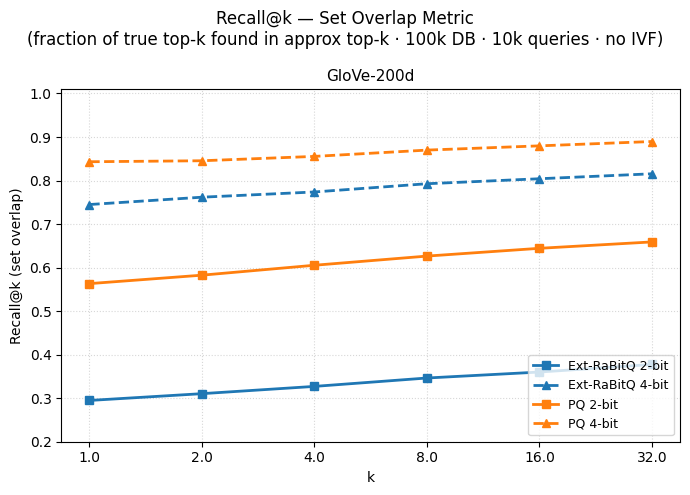

Saved: recall_set_overlap.png


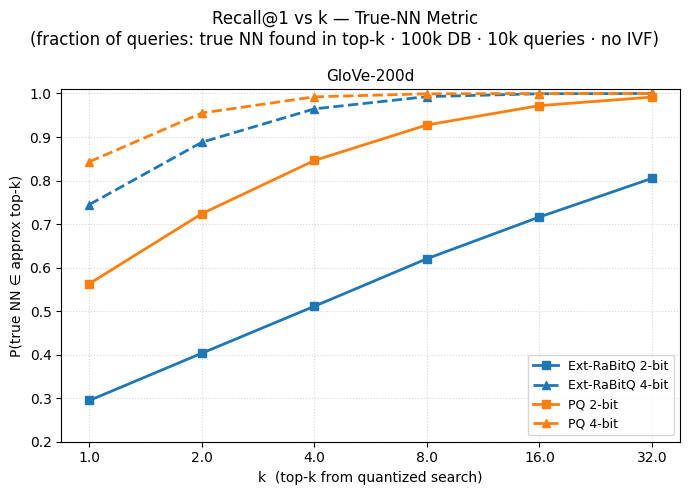

Saved: recall1_at_k.png

── Set Overlap (compute_recalls) ──
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------

  GloVe-200d:
  Ext-RaBitQ-2bit      0.2948  0.3104  0.3271  0.3464  0.3601  0.3775
  Ext-RaBitQ-4bit      0.7449  0.7618  0.7738  0.7927  0.8041  0.8155
  PQ-2bit              0.5632  0.5826  0.6054  0.6264  0.6443  0.6590
  PQ-4bit              0.8432  0.8455  0.8555  0.8699  0.8797  0.8897

── True-NN (recall1_at_k) ──
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------

  GloVe-200d:
  Ext-RaBitQ-2bit      0.2948  0.4034  0.5112  0.6204  0.7162  0.8050
  Ext-RaBitQ-4bit      0.7449  0.8880  0.9647  0.9928  0.9994  1.0000
  PQ-2bit              0.5632  0.7239  0.8461  0.9277  0.9721  0.9917
  PQ-4bit              0.8432  0.9552  0.9923  0.9993  0.9999  1.0000


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHODS_TO_PLOT = ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit", "PQ-2bit", "PQ-4bit"]

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
}

DIMS_TO_PLOT = sorted(all_results.keys())

# ───────────── Plot 1: compute_recalls (Set Overlap) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@k — Set Overlap Metric\n"
             "(fraction of true top-k found in approx top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        res = all_results.get(dim, {}).get(method)
        if res is None:
            continue
        ks = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **STYLE[method])

    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k (set overlap)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        res[k]
        for method in METHODS_TO_PLOT
        for res in [all_results.get(dim, {}).get(method)]
        if res is not None
        for k in res
    ]
    if all_vals:
        ymin = max(0.0, min(all_vals) - 0.05)
        ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_set_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall_set_overlap.png")

# ───────────── Plot 2: recall1_at_k (True-NN) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@1 vs k — True-NN Metric\n"
             "(fraction of queries: true NN found in top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None:
            continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **STYLE[method])

    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("P(true NN ∈ approx top-k)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        curve[k]
        for method in METHODS_TO_PLOT
        for curve in [all_rec1.get(dim, {}).get(method)]
        if curve is not None
        for k in curve
    ]
    if all_vals:
        ymin = max(0.0, min(all_vals) - 0.05)
        ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall1_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall1_at_k.png")

# ───────────── Print both tables ─────────────
for title, data_dict in [("Set Overlap (compute_recalls)", all_results),
                          ("True-NN (recall1_at_k)",        all_rec1)]:
    print(f"\n── {title} ──")
    print(f"{'Method':<20} {'R@1':>6} {'R@2':>6} {'R@4':>6} {'R@8':>6} {'R@16':>6} {'R@32':>6}")
    print("-" * 56)
    for dim in DIMS_TO_PLOT:
        dataset_name = "GloVe" if dim == 200 else "OpenAI"
        print(f"\n  {dataset_name}-{dim}d:")
        for method in METHODS_TO_PLOT:
            curve = data_dict.get(dim, {}).get(method)
            if curve is None:
                continue
            vals = [f"{curve[k]:.4f}" for k in sorted(curve.keys())]
            print(f"  {method:<20} {'  '.join(vals)}")

In [28]:
# =========================
# PRECOMPUTE ROTATION ONCE
# =========================
rng = np.random.RandomState(42)

def get_rotation(dim):
    R = np.linalg.qr(rng.randn(dim, dim))[0].astype(np.float32)
    return R


def run_one(kind, label, dim, X, Xq, GT, R=None, **kw):
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    try:
        t0 = time.time()

        # =========================
        # EXT RABITQ (FIXED VERSION)
        # =========================
        if kind == "ext_rabitq":
            qb = kw["qb"]
        
            print(f"    Building RaBitQ (qb={qb}) + fixed rotation …", flush=True)
        
            # use precomputed rotation
            X_rot  = X @ R.T
            Xq_rot = Xq @ R.T
        
            idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
            idx.qb = qb
        
            idx.train(X_rot)
        
            for s in range(0, len(X_rot), 10_000):
                idx.add(X_rot[s:s+10_000])
        
            print(f"    code_size={idx.code_size} bytes ({idx.code_size*8} bits)", flush=True)
        
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
        
            _, I = idx.search(Xq_rot, K_GT)
        # =========================
        # PQ (FULL DATA TRAINING)
        # =========================
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]

            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}")
                return None, None

            print(f"    Training PQ m={m} nbits={nbits} on FULL data …", flush=True)

            idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)

            t_train = time.time()
            idx.train(X)
            print(f"    PQ training time: {time.time() - t_train:.1f}s", flush=True)

            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

            print(f"    PQ bits/vector = {m * nbits}", flush=True)

            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)

            _, I = idx.search(Xq, K_GT)

        else:
            raise ValueError(f"Unknown kind: {kind}")

        # =========================
        # RECALL
        # =========================
        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)

        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)

        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None

    finally:
        try: del idx
        except: pass
        aggressive_gc()


# =========================
# MAIN LOOP
# =========================
for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  {'GloVe' if col == 'glove_angular' else 'OpenAI'} {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    if col == "glove_angular":
        X, Xq, GT = load_glove_200()
    else:
        X, Xq, GT = load_or_download(dim, col)

    print(f"  Base: {X.shape}  Queries: {Xq.shape}  GT: {GT.shape}")

    # ===== FIXED ROTATION =====
    R = get_rotation(dim)

    dim_res, dim_rec1 = {}, {}

    # =========================
    # METHODS (CLEAN + FAIR)
    # =========================
    METHODS = [
        # RaBitQ (precision variants, NOT bitrate)
        ("ext_rabitq", "Ext-RaBitQ-qb2", {"qb": 2}),
        ("ext_rabitq", "Ext-RaBitQ-qb4", {"qb": 4}),

        # PQ true bitrate variants
        ("pq", "PQ-2bit", {"m": dim // 4, "nbits": 8}),
        ("pq", "PQ-4bit", {"m": dim // 2, "nbits": 8}),

        # OPTIONAL: match RaBitQ bitrate (~264 bits)
        ("pq", "PQ-matched", {"m": 33, "nbits": 8}),
    ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, R=R, **kwargs)

        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1

    del X, Xq, GT
    aggressive_gc()

    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  GloVe 200d  |  RAM free: 22.9 GB
  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
  Base: (100000, 200)  Queries: (10000, 200)  GT: (10000, 32)

  ▶ Ext-RaBitQ-qb2  (RAM free: 22.8 GB)
    Building RaBitQ (qb=2) + fixed rotation …
    code_size=33 bytes (264 bits)
    Searching … (RAM free: 22.7 GB)
  [Ext-RaBitQ-qb2] R@1:0.2123  R@2:0.2248  R@4:0.2375  R@8:0.2505  R@16:0.2636  R@32:0.2768
    (6s)

  ▶ Ext-RaBitQ-qb4  (RAM free: 22.7 GB)
    Building RaBitQ (qb=4) + fixed rotation …
    code_size=33 bytes (264 bits)
    Searching … (RAM free: 22.7 GB)
  [Ext-RaBitQ-qb4] R@1:0.3039  R@2:0.3174  R@4:0.3365  R@8:0.3528  R@16:0.3652  R@32:0.3797
    (7s)

  ▶ PQ-2bit  (RAM free: 22.8 GB)
    Training PQ m=50 nbits=8 on FULL data …
    PQ training time: 5.2s
    PQ bits/vector = 400
    Searching … (RAM free: 22.8 GB)
  [PQ-2bit] R@1:0.5613  R@2:0.5834  R@4:0.6087  R@8:0.6258  R@16:0.6459  R@32:0.6609
    (16s)

  ▶ PQ-4bit  (RAM free: 22.7 GB)


In [43]:
import numpy as np
import faiss
import time
import gc
import matplotlib.pyplot as plt

K_GT = 32

# -------------------------
# Helpers
# -------------------------
def aggressive_gc():
    gc.collect()

def recall_at_1(I, GT):
    return (I[:, 0] == GT[:, 0]).mean()

# -------------------------
# Load Data
# -------------------------
X, Xq, _ = load_glove_200()
dim = X.shape[1]

print("Loaded:", X.shape, Xq.shape)

# -------------------------
# 🔥 STEP 1: Normalize
# -------------------------
faiss.normalize_L2(X)
faiss.normalize_L2(Xq)

print("Mean norm X:", np.linalg.norm(X, axis=1).mean())
print("Mean norm Xq:", np.linalg.norm(Xq, axis=1).mean())

# -------------------------
# 🔥 STEP 2: Recompute GT
# -------------------------
print("\nRecomputing GT...")

index_exact = faiss.IndexFlatIP(dim)
index_exact.add(X)

_, GT = index_exact.search(Xq, K_GT)

# sanity check
_, I_exact = index_exact.search(Xq, 1)
print("GT sanity:", (I_exact[:, 0] == GT[:, 0]).mean())  # must be 1.0

# -------------------------
# RaBitQ
# -------------------------
def run_rabitq(qb):
    print(f"\n▶ RaBitQ (qb={qb})")
    t0 = time.time()

    idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
    idx.qb = qb

    idx.train(X)

    for s in range(0, len(X), 10000):
        idx.add(X[s:s+10000])

    bits = idx.code_size * 8
    print(f"bits/vector = {bits}")

    _, I = idx.search(Xq, K_GT)
    r1 = recall_at_1(I, GT)

    print(f"R@1: {r1:.4f} | Time: {time.time()-t0:.1f}s")

    return r1, bits

# -------------------------
# PQ
# -------------------------
def run_pq(label, m, nbits):
    print(f"\n▶ {label} (m={m}, nbits={nbits})")
    t0 = time.time()

    idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)

    idx.train(X)

    for s in range(0, len(X), 10000):
        idx.add(X[s:s+10000])

    bits = m * nbits
    print(f"bits/vector = {bits}")

    _, I = idx.search(Xq, K_GT)
    r1 = recall_at_1(I, GT)

    print(f"R@1: {r1:.4f} | Time: {time.time()-t0:.1f}s")

    return r1, bits

# -------------------------
# RUN EXPERIMENTS
# -------------------------
results = []

# RaBitQ (same bits, diff qb)
r1, bits = run_rabitq(qb=2)
results.append(("RaBitQ-qb2", bits, r1))

r1, bits = run_rabitq(qb=4)
results.append(("RaBitQ-qb4", bits, r1))

# PQ variants
r1, bits = run_pq("PQ-2bit", m=dim//4, nbits=8)
results.append(("PQ-2bit", bits, r1))

r1, bits = run_pq("PQ-4bit", m=dim//2, nbits=8)
results.append(("PQ-4bit", bits, r1))

# 🔥 MATCHED BITRATE (important!)
r1, bits = run_pq("PQ-matched", m=33, nbits=8)
results.append(("PQ-matched", bits, r1))

# -------------------------
# PRINT TABLE
# -------------------------
print("\n=== FINAL COMPARISON ===")
print(f"{'Method':15s} {'Bits':>8s} {'R@1':>8s}")
print("-"*32)
for name, bits, r1 in results:
    print(f"{name:15s} {bits:8d} {r1:8.4f}")

# -------------------------
# 📈 PLOT (KEY RESULT)
# -------------------------
plt.figure()

for name, bits, r1 in results:
    plt.scatter(bits, r1)
    plt.text(bits, r1, name)

plt.xlabel("Bits per vector")
plt.ylabel("Recall@1")
plt.title("Recall vs Bits (Fair Comparison)")
plt.grid()

plt.savefig("recall_vs_bits.png")
plt.show()

print("\nSaved plot: recall_vs_bits.png")

  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
Loaded: (100000, 200) (10000, 200)
Mean norm X: 1.0
Mean norm Xq: 1.0

Recomputing GT...
GT sanity: 1.0

▶ RaBitQ (qb=2)
bits/vector = 264
R@1: 0.2068 | Time: 4.5s

▶ RaBitQ (qb=4)
bits/vector = 264
R@1: 0.3077 | Time: 6.1s

▶ PQ-2bit (m=50, nbits=8)
bits/vector = 400
R@1: 0.5629 | Time: 14.2s

▶ PQ-4bit (m=100, nbits=8)
bits/vector = 800
R@1: 0.8422 | Time: 21.3s

▶ PQ-matched (m=33, nbits=8)


RuntimeError: Error in void faiss::ProductQuantizer::set_derived_values() at /project/third-party/faiss/faiss/impl/ProductQuantizer.cpp:59: Error: '!(d % M == 0)' failed: The dimension of the vector (d) should be a multiple of the number of subquantizers (M)

In [41]:

X, Xq, GT = load_glove_200()  # your loader

dim = X.shape[1]
run_rabitq(dim, X, Xq, GT, qb=2)
run_rabitq(dim, X, Xq, GT, qb=4)

  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)

▶ RaBitQ (qb=2)  | RAM free: 22.8 GB
  code_size = 33 bytes (264 bits)
  Searching...
  [RaBitQ-qb2] R@1:0.2068  R@2:0.2212  R@4:0.2347  R@8:0.2437  R@16:0.2549  R@32:0.2673
  Time: 4.9s

▶ RaBitQ (qb=4)  | RAM free: 22.8 GB
  code_size = 33 bytes (264 bits)
  Searching...
  [RaBitQ-qb4] R@1:0.3077  R@2:0.3182  R@4:0.3334  R@8:0.3459  R@16:0.3606  R@32:0.3742
  Time: 6.6s


({1: 0.3077, 2: 0.31825, 4: 0.3334, 8: 0.3459, 16: 0.3606, 32: 0.37418125},
 {1: 0.3077, 2: 0.4173, 4: 0.531, 8: 0.6411, 16: 0.7377, 32: 0.8197})

In [37]:
import faiss

# normalize FIRST
faiss.normalize_L2(X)
faiss.normalize_L2(Xq)

# exact search
index = faiss.IndexFlatIP(X.shape[1])
index.add(X)

_, GT = index.search(Xq, 32)

In [38]:
_, I_exact = index.search(Xq, 1)
print((I_exact[:,0] == GT[:,0]).mean())  # should be 1.0

1.0


  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
Loaded: (100000, 200) (10000, 200)
Mean norm X: 1.0
Mean norm Xq: 1.0

Recomputing GT...
GT sanity: 1.0

▶ RaBitQ (qb=2)
bits/vector = 264
RaBitQ-qb2: R@1:0.2068  R@2:0.2910  R@4:0.3846  R@8:0.4804  R@16:0.5759  R@32:0.6682  
Time: 4.6s

▶ RaBitQ (qb=4)
bits/vector = 264
RaBitQ-qb4: R@1:0.3077  R@2:0.4173  R@4:0.5310  R@8:0.6411  R@16:0.7377  R@32:0.8197  
Time: 6.3s

▶ PQ-200bits (m=25, nbits=8)
bits/vector = 200
PQ-200bits: R@1:0.3075  R@2:0.4217  R@4:0.5393  R@8:0.6518  R@16:0.7504  R@32:0.8328  
Time: 6.5s

▶ PQ-320bits (m=40, nbits=8)
bits/vector = 320
PQ-320bits: R@1:0.4665  R@2:0.6155  R@4:0.7496  R@8:0.8536  R@16:0.9239  R@32:0.9661  
Time: 8.8s

▶ PQ-2bit (m=50, nbits=8)
bits/vector = 400
PQ-2bit: R@1:0.5629  R@2:0.7172  R@4:0.8474  R@8:0.9301  R@16:0.9732  R@32:0.9920  
Time: 14.4s

▶ PQ-4bit (m=100, nbits=8)
bits/vector = 800
PQ-4bit: R@1:0.8422  R@2:0.9517  R@4:0.9908  R@8:0.9988  R@1

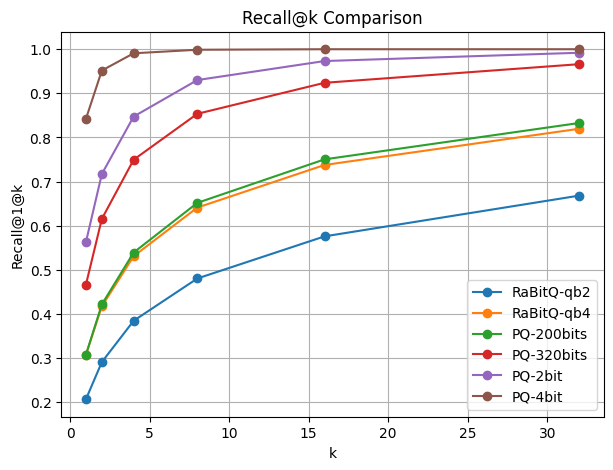


Saved plot: recall_at_k.png


In [47]:
import numpy as np
import faiss
import time
import gc
import matplotlib.pyplot as plt

K_GT = 32
KS = [1, 2, 4, 8, 16, 32]

# -------------------------
# Helpers
# -------------------------
def aggressive_gc():
    gc.collect()

def recall1_at_k(I, GT):
    res = {}
    for k in KS:
        correct = 0
        for i in range(len(I)):
            if GT[i, 0] in I[i, :k]:
                correct += 1
        res[k] = correct / len(I)
    return res

def print_recall_curve(label, rec):
    print(f"{label}: ", end="")
    for k in KS:
        print(f"R@{k}:{rec[k]:.4f}", end="  ")
    print()

# -------------------------
# Load Data
# -------------------------
X, Xq, _ = load_glove_200()
dim = X.shape[1]

print("Loaded:", X.shape, Xq.shape)

# -------------------------
# STEP 1: Normalize
# -------------------------
faiss.normalize_L2(X)
faiss.normalize_L2(Xq)

print("Mean norm X:", np.linalg.norm(X, axis=1).mean())
print("Mean norm Xq:", np.linalg.norm(Xq, axis=1).mean())

# -------------------------
# STEP 2: Recompute GT
# -------------------------
print("\nRecomputing GT...")

index_exact = faiss.IndexFlatIP(dim)
index_exact.add(X)

_, GT = index_exact.search(Xq, K_GT)

# sanity check
_, I_exact = index_exact.search(Xq, 1)
print("GT sanity:", (I_exact[:, 0] == GT[:, 0]).mean())

# -------------------------
# RaBitQ
# -------------------------
def run_rabitq(qb):
    print(f"\n▶ RaBitQ (qb={qb})")
    t0 = time.time()

    idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
    idx.qb = qb

    idx.train(X)

    for s in range(0, len(X), 10000):
        idx.add(X[s:s+10000])

    bits = idx.code_size * 8
    print(f"bits/vector = {bits}")

    _, I = idx.search(Xq, K_GT)
    rec = recall1_at_k(I, GT)

    print_recall_curve("RaBitQ-qb{}".format(qb), rec)
    print(f"Time: {time.time()-t0:.1f}s")

    return rec, bits

# -------------------------
# PQ
# -------------------------
def run_pq(label, m, nbits):
    print(f"\n▶ {label} (m={m}, nbits={nbits})")
    t0 = time.time()

    idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)

    idx.train(X)

    for s in range(0, len(X), 10000):
        idx.add(X[s:s+10000])

    bits = m * nbits
    print(f"bits/vector = {bits}")

    _, I = idx.search(Xq, K_GT)
    rec = recall1_at_k(I, GT)

    print_recall_curve(label, rec)
    print(f"Time: {time.time()-t0:.1f}s")

    return rec, bits

# -------------------------
# RUN ALL
# -------------------------
results = []

# RaBitQ
rec, bits = run_rabitq(qb=2)
results.append(("RaBitQ-qb2", bits, rec))

rec, bits = run_rabitq(qb=4)
results.append(("RaBitQ-qb4", bits, rec))

# PQ (valid configs)
rec, bits = run_pq("PQ-200bits", m=25, nbits=8)
results.append(("PQ-200bits", bits, rec))

rec, bits = run_pq("PQ-320bits", m=40, nbits=8)
results.append(("PQ-320bits", bits, rec))

rec, bits = run_pq("PQ-2bit", m=dim//4, nbits=8)
results.append(("PQ-2bit", bits, rec))

rec, bits = run_pq("PQ-4bit", m=dim//2, nbits=8)
results.append(("PQ-4bit", bits, rec))

# -------------------------
# PRINT TABLE (R@1)
# -------------------------
print("\n=== SUMMARY (R@1) ===")
print(f"{'Method':15s} {'Bits':>8s} {'R@1':>8s}")
print("-"*32)
for name, bits, rec in results:
    print(f"{name:15s} {bits:8d} {rec[1]:8.4f}")

# -------------------------
# 📈 PLOT: Recall@k curves
# -------------------------
plt.figure(figsize=(7,5))

for name, bits, rec in results:
    y = [rec[k] for k in KS]
    plt.plot(KS, y, marker='o', label=name)

plt.xlabel("k")
plt.ylabel("Recall@1@k")
plt.title("Recall@k Comparison")
plt.legend()
plt.grid()

plt.savefig("recall_at_k.png")
plt.show()

print("\nSaved plot: recall_at_k.png")

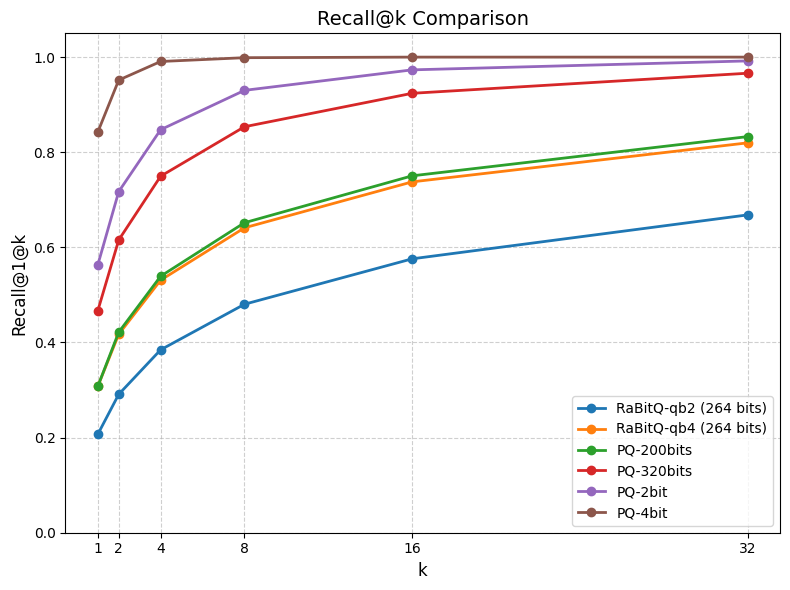

Saved: recall_at_k.png


In [48]:
import matplotlib.pyplot as plt

KS = [1, 2, 4, 8, 16, 32]

plt.figure(figsize=(8,6))

for name, bits, rec in results:
    y = [rec[k] for k in KS]

    # nicer labels
    if "RaBitQ" in name:
        label = f"{name} ({bits} bits)"
    else:
        label = f"{name}"

    plt.plot(KS, y, marker='o', linewidth=2, label=label)

# formatting
plt.xlabel("k", fontsize=12)
plt.ylabel("Recall@1@k", fontsize=12)
plt.title("Recall@k Comparison", fontsize=14)

plt.xticks(KS)
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig("recall_at_k.png", dpi=300)
plt.show()

print("Saved: recall_at_k.png")

In [49]:
def get_rotation_matrix(dim, seed=42):
    rng = np.random.RandomState(seed)
    A = rng.randn(dim, dim).astype(np.float32)
    Q, _ = np.linalg.qr(A)
    return Q.astype(np.float32)

In [50]:
# normalize first
faiss.normalize_L2(X)
faiss.normalize_L2(Xq)

# rotation
R = get_rotation_matrix(dim)

X_rot  = X @ R
Xq_rot = Xq @ R

In [51]:
index_exact = faiss.IndexFlatIP(dim)
index_exact.add(X_rot)

_, GT = index_exact.search(Xq_rot, K_GT)

In [52]:
def run_ext_rabitq(qb):
    print(f"\n▶ Ext-RaBitQ (qb={qb})")
    t0 = time.time()

    idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
    idx.qb = qb

    idx.train(X_rot)

    for s in range(0, len(X_rot), 10000):
        idx.add(X_rot[s:s+10000])

    bits = idx.code_size * 8
    print(f"bits/vector = {bits}")

    _, I = idx.search(Xq_rot, K_GT)
    rec = recall1_at_k(I, GT)

    print_recall_curve(f"Ext-RaBitQ-qb{qb}", rec)
    print(f"Time: {time.time()-t0:.1f}s")

    return rec, bits

In [53]:
run_ext_rabitq(qb=2)
run_ext_rabitq(qb=4)


▶ Ext-RaBitQ (qb=2)
bits/vector = 264
Ext-RaBitQ-qb2: R@1:0.2154  R@2:0.3012  R@4:0.3900  R@8:0.4830  R@16:0.5752  R@32:0.6650  
Time: 4.6s

▶ Ext-RaBitQ (qb=4)
bits/vector = 264
Ext-RaBitQ-qb4: R@1:0.3119  R@2:0.4261  R@4:0.5397  R@8:0.6461  R@16:0.7362  R@32:0.8199  
Time: 6.3s


({1: 0.3119, 2: 0.4261, 4: 0.5397, 8: 0.6461, 16: 0.7362, 32: 0.8199}, 264)

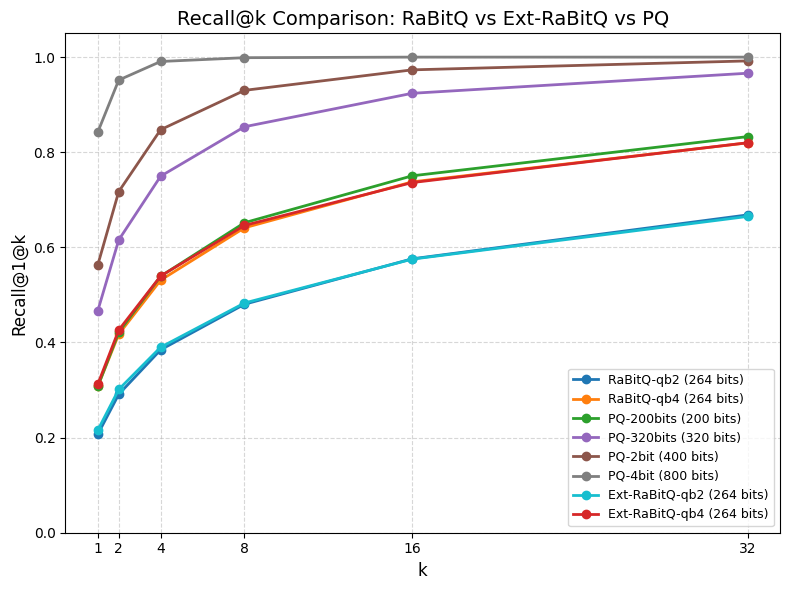

Saved: final_recall_at_k.png


In [57]:
import matplotlib.pyplot as plt

KS = [1, 2, 4, 8, 16, 32]

# consistent colors
colors = {
    "Ext-RaBitQ-qb2": "#17becf",
    "Ext-RaBitQ-qb4": "#d62728",
    "PQ-200bits": "#2ca02c",
    "PQ-320bits": "#9467bd",
    "PQ-2bit": "#8c564b",
    "PQ-4bit": "#7f7f7f",
}

plt.figure(figsize=(8,6))

for name, bits, rec in results:
    y = [rec[k] for k in KS]
    
    color = colors.get(name, None)
    
    # nicer label
    label = f"{name} ({bits} bits)"
    
    plt.plot(
        KS,
        y,
        marker='o',
        linewidth=2,
        markersize=6,
        label=label,
        color=color
    )

# styling
plt.xlabel("k", fontsize=12)
plt.ylabel("Recall@1@k", fontsize=12)
plt.title("Recall@k Comparison: RaBitQ vs Ext-RaBitQ vs PQ", fontsize=14)

plt.xticks(KS)
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig("final_recall_at_k.png", dpi=300)
plt.show()

print("Saved: final_recall_at_k.png")

In [55]:
rec, bits = run_ext_rabitq(qb=2)
results.append(("Ext-RaBitQ-qb2", bits, rec))

rec, bits = run_ext_rabitq(qb=4)
results.append(("Ext-RaBitQ-qb4", bits, rec))


▶ Ext-RaBitQ (qb=2)
bits/vector = 264
Ext-RaBitQ-qb2: R@1:0.2154  R@2:0.3012  R@4:0.3900  R@8:0.4830  R@16:0.5752  R@32:0.6650  
Time: 4.6s

▶ Ext-RaBitQ (qb=4)
bits/vector = 264
Ext-RaBitQ-qb4: R@1:0.3119  R@2:0.4261  R@4:0.5397  R@8:0.6461  R@16:0.7362  R@32:0.8199  
Time: 6.4s


In [60]:
import numpy as np
import faiss
import time
import gc

K_GT = 32
KS = [1,2,4,8,16,32]

# -------------------------
# Helpers
# -------------------------
def recall1_at_k(I, GT):
    res = {}
    for k in KS:
        correct = 0
        for i in range(len(I)):
            if GT[i,0] in I[i,:k]:
                correct += 1
        res[k] = correct / len(I)
    return res

def print_rec(label, rec):
    print(f"{label}: ", end="")
    for k in KS:
        print(f"R@{k}:{rec[k]:.4f}", end="  ")
    print()

def aggressive_gc():
    gc.collect()

# -------------------------
# Rotation (ORTHOGONAL)
# -------------------------
def make_rotation(dim, seed=42):
    rng = np.random.RandomState(seed)
    A = rng.randn(dim, dim).astype(np.float32)
    Q, _ = np.linalg.qr(A)
    return Q.astype(np.float32)

# -------------------------
# MAIN PIPELINE
# -------------------------
def run_ext_rabitq_pipeline(X, Xq):

    dim = X.shape[1]

    print("Step 1: Normalize")
    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    print("Step 2: Build rotation")
    R = make_rotation(dim)

    # 🔥 IMPORTANT: SAME rotation for both
    X_rot  = X @ R
    Xq_rot = Xq @ R

    print("Step 3: Recompute GT (ROTATED space)")
    index_exact = faiss.IndexFlatIP(dim)
    index_exact.add(X_rot)

    _, GT = index_exact.search(Xq_rot, K_GT)

    # sanity check
    _, I_chk = index_exact.search(Xq_rot, 1)
    print("GT sanity:", (I_chk[:,0] == GT[:,0]).mean())

    # -------------------------
    # Run Ext-RaBitQ
    # -------------------------
    results = []

    for qb in [2,4]:
        print(f"\n▶ Ext-RaBitQ (qb={qb})")

        t0 = time.time()

        idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
        idx.qb = qb

        # train on rotated data
        idx.train(X_rot)

        # add in batches
        for i in range(0, len(X_rot), 10000):
            idx.add(X_rot[i:i+10000])

        bits = idx.code_size * 8
        print(f"bits/vector = {bits}")

        # search on rotated queries
        _, I = idx.search(Xq_rot, K_GT)

        rec = recall1_at_k(I, GT)
        print_rec(f"Ext-RaBitQ-qb{qb}", rec)

        print(f"Time: {time.time()-t0:.2f}s")

        results.append((f"Ext-RaBitQ-qb{qb}", bits, rec))

        aggressive_gc()

    return results

In [62]:
# =========================
# ALL FUNCTIONS + RUN
# =========================

# ---- paste ALL your functions here ----
# (recall1_at_k, print_rec, make_rotation, etc.)

# ---- ADD THIS (baseline RaBitQ) ----
def run_rabitq_pipeline(X, Xq):
    dim = X.shape[1]
    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    index_exact = faiss.IndexFlatIP(dim)
    index_exact.add(X)
    _, GT = index_exact.search(Xq, K_GT)

    results = []

    for qb in [2,4]:
        idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
        idx.qb = qb
        idx.train(X)

        for i in range(0, len(X), 10000):
            idx.add(X[i:i+10000])

        bits = idx.code_size * 8
        _, I = idx.search(Xq, K_GT)

        rec = recall1_at_k(I, GT)
        results.append((f"RaBitQ-qb{qb}", bits, rec))

    return results


# ---- ADD THIS (PQ) ----
def run_pq_pipeline(X, Xq):
    dim = X.shape[1]
    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    index_exact = faiss.IndexFlatIP(dim)
    index_exact.add(X)
    _, GT = index_exact.search(Xq, K_GT)

    results = []

    configs = [
        ("PQ-200bits", 25, 8),
        ("PQ-320bits", 40, 8),
    ]

    for name, m, nbits in configs:
        idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)
        idx.train(X)

        for i in range(0, len(X), 10000):
            idx.add(X[i:i+10000])

        bits = m * nbits
        _, I = idx.search(Xq, K_GT)

        rec = recall1_at_k(I, GT)
        results.append((name, bits, rec))

    return results


# =========================
# RUN
# =========================

rabitq_res = run_rabitq_pipeline(X.copy(), Xq.copy())
ext_res    = run_ext_rabitq_pipeline(X.copy(), Xq.copy())
pq_res     = run_pq_pipeline(X.copy(), Xq.copy())

results = rabitq_res + ext_res + pq_res

print("Done. Results ready.")

Step 1: Normalize
Step 2: Build rotation
Step 3: Recompute GT (ROTATED space)
GT sanity: 1.0

▶ Ext-RaBitQ (qb=2)
bits/vector = 264
Ext-RaBitQ-qb2: R@1:0.2154  R@2:0.3012  R@4:0.3900  R@8:0.4830  R@16:0.5752  R@32:0.6650  
Time: 4.59s

▶ Ext-RaBitQ (qb=4)
bits/vector = 264
Ext-RaBitQ-qb4: R@1:0.3119  R@2:0.4261  R@4:0.5397  R@8:0.6461  R@16:0.7362  R@32:0.8199  
Time: 6.36s
Done. Results ready.


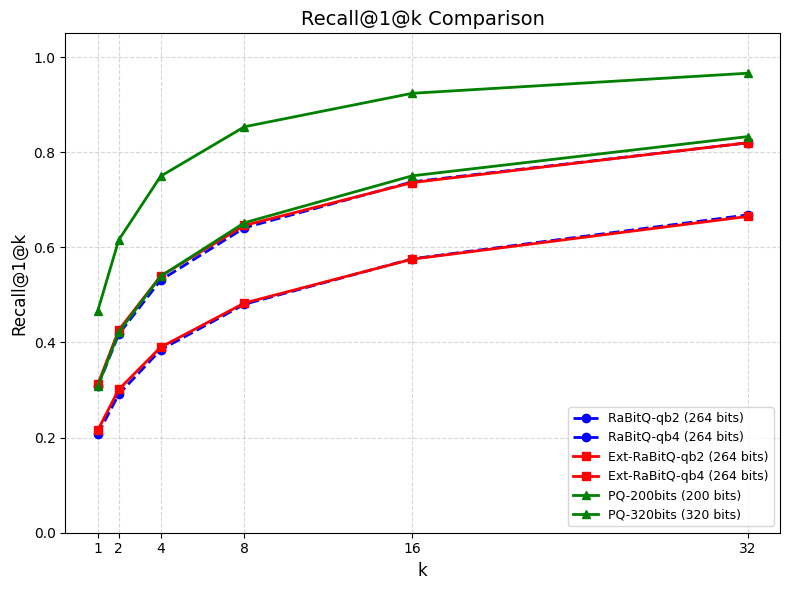

Saved: recall_at_k.png


In [64]:
import matplotlib.pyplot as plt

KS = [1, 2, 4, 8, 16, 32]

plt.figure(figsize=(8,6))

for name, bits, rec in results:
    y = [rec[k] for k in KS]

    # styling by method
    if "Ext-RaBitQ" in name:
        color = "red"
        linestyle = "-"
        marker = "s"
    elif "RaBitQ" in name:
        color = "blue"
        linestyle = "--"
        marker = "o"
    elif "PQ" in name:
        color = "green"
        linestyle = "-"
        marker = "^"
    else:
        color = "black"
        linestyle = "-"
        marker = "o"

    label = f"{name} ({bits} bits)"

    plt.plot(
        KS, y,
        marker=marker,
        linestyle=linestyle,
        linewidth=2,
        markersize=6,
        color=color,
        label=label
    )

# axes
plt.xlabel("k", fontsize=12)
plt.ylabel("Recall@1@k", fontsize=12)
plt.title("Recall@1@k Comparison", fontsize=14)

plt.xticks(KS)
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig("recall_at_k.png", dpi=300)
plt.show()

print("Saved: recall_at_k.png")

In [65]:
import numpy as np
import faiss
import time
import gc
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
K_GT = 32
KS = [1,2,4,8,16,32]

# -------------------------
# Helpers
# -------------------------
def recall1_at_k(I, GT):
    res = {}
    for k in KS:
        correct = 0
        for i in range(len(I)):
            if GT[i,0] in I[i,:k]:
                correct += 1
        res[k] = correct / len(I)
    return res

def print_rec(label, rec):
    print(f"{label}: ", end="")
    for k in KS:
        print(f"R@{k}:{rec[k]:.4f}", end="  ")
    print()

def make_rotation(dim, seed=42):
    rng = np.random.RandomState(seed)
    A = rng.randn(dim, dim).astype(np.float32)
    Q, _ = np.linalg.qr(A)
    return Q.astype(np.float32)

# -------------------------
# MAIN PIPELINE
# -------------------------
def run_pipeline_ext_vs_pq(X, Xq):

    dim = X.shape[1]

    print("Step 1: Normalize")
    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    print("Step 2: Rotation (Ext-RaBitQ)")
    R = make_rotation(dim)
    X_rot  = X @ R
    Xq_rot = Xq @ R

    print("Step 3: GT (ROTATED space)")
    index_exact = faiss.IndexFlatIP(dim)
    index_exact.add(X_rot)
    _, GT = index_exact.search(Xq_rot, K_GT)

    # sanity
    _, I_chk = index_exact.search(Xq_rot, 1)
    print("GT sanity:", (I_chk[:,0] == GT[:,0]).mean())

    results = []

    # =================================================
    # 🔴 Ext-RaBitQ
    # =================================================
    for qb in [2,4]:
        print(f"\n▶ Ext-RaBitQ (qb={qb})")

        t0 = time.time()

        idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
        idx.qb = qb

        idx.train(X_rot)

        for i in range(0, len(X_rot), 10000):
            idx.add(X_rot[i:i+10000])

        bits = idx.code_size * 8

        _, I = idx.search(Xq_rot, K_GT)
        rec = recall1_at_k(I, GT)

        print_rec(f"Ext-RaBitQ-qb{qb}", rec)
        print(f"bits={bits} time={time.time()-t0:.2f}s")

        results.append((f"Ext-RaBitQ-qb{qb}", bits, rec))


    # =================================================
    # 🟢 PQ (STRUCTURE-ALIGNED)
    # =================================================
    print("\n--- PQ (aligned with RaBitQ) ---")

    for bits_per_coordinate in [2,4]:

        if bits_per_coordinate == 2:
            group_size = 4
        else:
            group_size = 2

        m = dim // group_size
        nbits = bits_per_coordinate * group_size  # = 8

        label = f"PQ-{bits_per_coordinate}bit-aligned"

        print(f"\n▶ {label} (m={m}, nbits={nbits})")

        t0 = time.time()

        idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)

        idx.train(X_rot)

        for i in range(0, len(X_rot), 10000):
            idx.add(X_rot[i:i+10000])

        bits = m * nbits

        _, I = idx.search(Xq_rot, K_GT)
        rec = recall1_at_k(I, GT)

        print_rec(label, rec)
        print(f"bits={bits} time={time.time()-t0:.2f}s")

        results.append((label, bits, rec))

    return results

In [66]:
results = run_pipeline_ext_vs_pq(X.copy(), Xq.copy())

Step 1: Normalize
Step 2: Rotation (Ext-RaBitQ)
Step 3: GT (ROTATED space)
GT sanity: 1.0

▶ Ext-RaBitQ (qb=2)
Ext-RaBitQ-qb2: R@1:0.2154  R@2:0.3012  R@4:0.3900  R@8:0.4830  R@16:0.5752  R@32:0.6650  
bits=264 time=4.58s

▶ Ext-RaBitQ (qb=4)
Ext-RaBitQ-qb4: R@1:0.3119  R@2:0.4261  R@4:0.5397  R@8:0.6461  R@16:0.7362  R@32:0.8199  
bits=264 time=6.28s

--- PQ (aligned with RaBitQ) ---

▶ PQ-2bit-aligned (m=50, nbits=8)
PQ-2bit-aligned: R@1:0.5670  R@2:0.7256  R@4:0.8479  R@8:0.9274  R@16:0.9735  R@32:0.9914  
bits=400 time=14.94s

▶ PQ-4bit-aligned (m=100, nbits=8)
PQ-4bit-aligned: R@1:0.8415  R@2:0.9569  R@4:0.9930  R@8:0.9989  R@16:1.0000  R@32:1.0000  
bits=800 time=22.64s


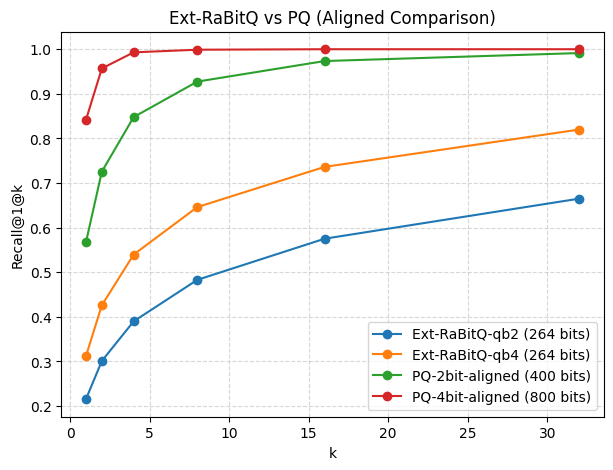

In [67]:
plt.figure(figsize=(7,5))

for name, bits, rec in results:
    y = [rec[k] for k in KS]
    plt.plot(KS, y, marker='o', label=f"{name} ({bits} bits)")

plt.xlabel("k")
plt.ylabel("Recall@1@k")
plt.title("Ext-RaBitQ vs PQ (Aligned Comparison)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [68]:
def run_pq_bits_pipeline(X, Xq):

    dim = X.shape[1]

    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    index_exact = faiss.IndexFlatIP(dim)
    index_exact.add(X)
    _, GT = index_exact.search(Xq, K_GT)

    results = []

    configs = [
        ("PQ-200bits", 25, 8),   # 25*8 = 200
        ("PQ-320bits", 40, 8),   # 40*8 = 320
        ("PQ-400bits", 50, 8),
        ("PQ-800bits", 100, 8),
    ]

    for name, m, nbits in configs:
        print(f"\n▶ {name}")

        idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)
        idx.train(X)

        for i in range(0, len(X), 10000):
            idx.add(X[i:i+10000])

        bits = m * nbits

        _, I = idx.search(Xq, K_GT)
        rec = recall1_at_k(I, GT)

        print_rec(name, rec)

        results.append((name, bits, rec))

    return results

In [69]:
ext_results = run_ext_rabitq_pipeline(X.copy(), Xq.copy())
pq_results  = run_pq_bits_pipeline(X.copy(), Xq.copy())

results = ext_results + pq_results

Step 1: Normalize
Step 2: Build rotation
Step 3: Recompute GT (ROTATED space)
GT sanity: 1.0

▶ Ext-RaBitQ (qb=2)
bits/vector = 264
Ext-RaBitQ-qb2: R@1:0.2154  R@2:0.3012  R@4:0.3900  R@8:0.4830  R@16:0.5752  R@32:0.6650  
Time: 4.59s

▶ Ext-RaBitQ (qb=4)
bits/vector = 264
Ext-RaBitQ-qb4: R@1:0.3119  R@2:0.4261  R@4:0.5397  R@8:0.6461  R@16:0.7362  R@32:0.8199  
Time: 6.29s

▶ PQ-200bits
PQ-200bits: R@1:0.3075  R@2:0.4217  R@4:0.5393  R@8:0.6518  R@16:0.7504  R@32:0.8328  

▶ PQ-320bits
PQ-320bits: R@1:0.4665  R@2:0.6155  R@4:0.7496  R@8:0.8536  R@16:0.9239  R@32:0.9661  

▶ PQ-400bits
PQ-400bits: R@1:0.5629  R@2:0.7172  R@4:0.8474  R@8:0.9301  R@16:0.9732  R@32:0.9920  

▶ PQ-800bits
PQ-800bits: R@1:0.8422  R@2:0.9517  R@4:0.9908  R@8:0.9988  R@16:1.0000  R@32:1.0000  


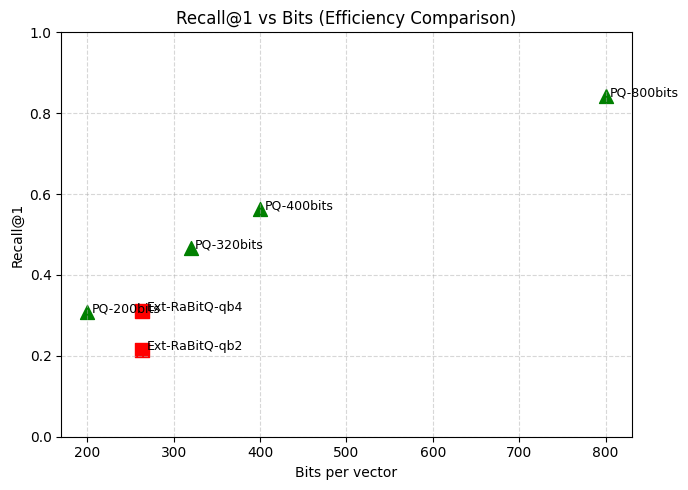

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for name, bits, rec in results:
    r1 = rec[1]

    if "Ext-RaBitQ" in name:
        color = "red"
        marker = "s"
    else:
        color = "green"
        marker = "^"

    plt.scatter(bits, r1, s=100, color=color, marker=marker)
    plt.text(bits + 5, r1, name, fontsize=9)

plt.xlabel("Bits per vector")
plt.ylabel("Recall@1")
plt.title("Recall@1 vs Bits (Efficiency Comparison)")

plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.0)

plt.tight_layout()
plt.savefig("recall_vs_bits.png", dpi=300)
plt.show()

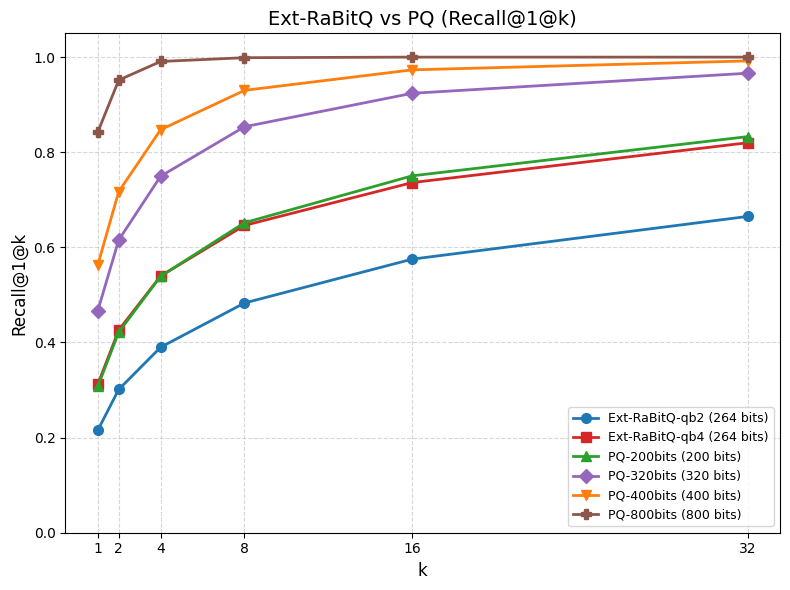

In [72]:
import matplotlib.pyplot as plt

KS = [1, 2, 4, 8, 16, 32]

# define distinct styles
styles = {
    "Ext-RaBitQ-qb2": {"color": "#1f77b4", "marker": "o"},   # blue
    "Ext-RaBitQ-qb4": {"color": "#d62728", "marker": "s"},   # red

    "PQ-200bits": {"color": "#2ca02c", "marker": "^"},       # green
    "PQ-320bits": {"color": "#9467bd", "marker": "D"},       # purple
    "PQ-400bits": {"color": "#ff7f0e", "marker": "v"},       # orange
    "PQ-800bits": {"color": "#8c564b", "marker": "P"},       # brown
}

plt.figure(figsize=(8,6))

for name, bits, rec in results:
    y = [rec[k] for k in KS]

    style = styles.get(name, {"color": "black", "marker": "o"})

    plt.plot(
        KS, y,
        color=style["color"],
        marker=style["marker"],
        linewidth=2,
        markersize=7,
        label=f"{name} ({bits} bits)"
    )

# formatting
plt.xlabel("k", fontsize=12)
plt.ylabel("Recall@1@k", fontsize=12)
plt.title("Ext-RaBitQ vs PQ (Recall@1@k)", fontsize=14)

plt.xticks(KS)
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig("colored_recall_at_k.png", dpi=300)
plt.show()

Loading data...
  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
Computing GT...

Running Ext-RaBitQ...

Running PQ...

=== Recall@k ===
Ext-RaBitQ-2bit : R@1:0.2108 R@2:0.2958 R@4:0.3944 R@8:0.4845 R@16:0.5790
Ext-RaBitQ-4bit : R@1:0.3055 R@2:0.4115 R@4:0.5234 R@8:0.6325 R@16:0.7271
PQ-2bit : R@1:0.5662 R@2:0.7224 R@4:0.8485 R@8:0.9274 R@16:0.9724
PQ-4bit : R@1:0.8436 R@2:0.9549 R@4:0.9923 R@8:0.9998 R@16:1.0000


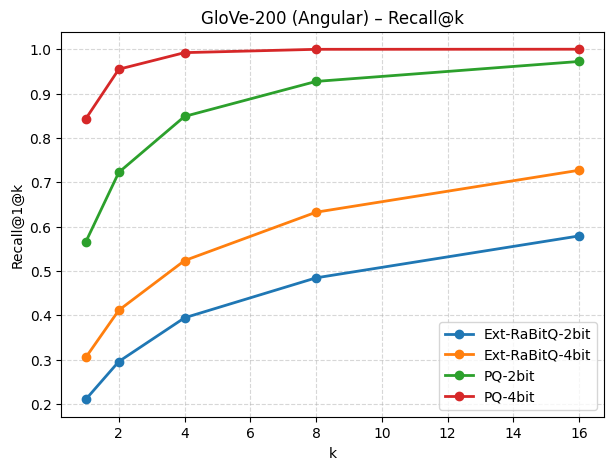

In [74]:
import numpy as np
import faiss
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
KS = [1,2,4,8,16]
K_MAX = max(KS)

# -------------------------
# LOAD + SAMPLE (GloVe-200)
# -------------------------
def load_data():
    X, Xq, _ = load_glove_200()  # assume already available

    rng = np.random.RandomState(42)

    X = X[rng.choice(len(X), 100000, replace=False)]
    Xq = Xq[rng.choice(len(Xq), 10000, replace=False)]

    # angular → normalize
    faiss.normalize_L2(X)
    faiss.normalize_L2(Xq)

    return X.astype(np.float32), Xq.astype(np.float32)

# -------------------------
# GT
# -------------------------
def compute_gt(X, Xq):
    index = faiss.IndexFlatIP(X.shape[1])
    index.add(X)
    _, GT = index.search(Xq, K_MAX)
    return GT

# -------------------------
# Recall@k
# -------------------------
def recall_at_k(I, GT):
    res = {}
    for k in KS:
        correct = 0
        for i in range(len(I)):
            if GT[i,0] in I[i,:k]:
                correct += 1
        res[k] = correct / len(I)
    return res

# -------------------------
# Ext-RaBitQ
# -------------------------
def run_ext_rabitq(X, Xq, GT, qb):

    dim = X.shape[1]

    # rotation
    R = np.linalg.qr(np.random.randn(dim, dim))[0].astype(np.float32)
    Xr = X @ R
    Xqr = Xq @ R

    idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
    idx.qb = qb

    idx.train(Xr)
    idx.add(Xr)

    _, I = idx.search(Xqr, K_MAX)

    return recall_at_k(I, GT)

# -------------------------
# PQ (ALIGNED)
# -------------------------
def run_pq(X, Xq, GT, bits_per_coord):

    dim = X.shape[1]

    if bits_per_coord == 2:
        group_size = 4
    else:
        group_size = 2

    m = dim // group_size
    nbits = bits_per_coord * group_size  # = 8

    idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)

    idx.train(X)
    idx.add(X)

    _, I = idx.search(Xq, K_MAX)

    return recall_at_k(I, GT)

# -------------------------
# RUN
# -------------------------
print("Loading data...")
X, Xq = load_data()

print("Computing GT...")
GT = compute_gt(X, Xq)

results = {}

print("\nRunning Ext-RaBitQ...")
results["Ext-RaBitQ-2bit"] = run_ext_rabitq(X, Xq, GT, qb=2)
results["Ext-RaBitQ-4bit"] = run_ext_rabitq(X, Xq, GT, qb=4)

print("\nRunning PQ...")
results["PQ-2bit"] = run_pq(X, Xq, GT, 2)
results["PQ-4bit"] = run_pq(X, Xq, GT, 4)

# -------------------------
# PRINT RESULTS
# -------------------------
print("\n=== Recall@k ===")
for name, rec in results.items():
    print(name, ":", " ".join([f"R@{k}:{rec[k]:.4f}" for k in KS]))

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(7,5))

for name, rec in results.items():
    y = [rec[k] for k in KS]
    plt.plot(KS, y, marker='o', linewidth=2, label=name)

plt.xlabel("k")
plt.ylabel("Recall@1@k")
plt.title("GloVe-200 (Angular) – Recall@k")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [75]:
print(np.mean(np.linalg.norm(X, axis=1)))

1.0


In [77]:
# exact index (same space as GT)
index_exact = faiss.IndexFlatIP(X.shape[1])
index_exact.add(X)

# get top-1 neighbors
_, I_chk = index_exact.search(Xq, 1)

# sanity check
print("GT sanity:", (I_chk[:,0] == GT[:,0]).mean())

GT sanity: 1.0


In [81]:
index_exact.add(X_rot)
_, I_chk = index_exact.search(Xq_rot, 1)

In [82]:
_, I_chk

(array([[0.37808594],
        [0.4221851 ],
        [0.45736262],
        ...,
        [0.53166425],
        [0.39356515],
        [0.4694303 ]], dtype=float32),
 array([[147864],
        [181639],
        [148080],
        ...,
        [105905],
        [159039],
        [153546]]))

In [79]:
index_exact.add(X)
_, I_chk = index_exact.search(Xq, 1)

In [80]:
_, I_chk

(array([[0.5824002 ],
        [0.3809736 ],
        [0.3873072 ],
        ...,
        [0.42116994],
        [0.38097453],
        [0.35360545]], dtype=float32),
 array([[79881],
        [68734],
        [89688],
        ...,
        [23530],
        [ 3300],
        [ 8849]]))

In [83]:
# 1. load + sample
X, Xq = load_data()

# 2. normalize
faiss.normalize_L2(X)
faiss.normalize_L2(Xq)

# 3. compute GT
index_exact = faiss.IndexFlatIP(X.shape[1])
index_exact.add(X)
_, GT = index_exact.search(Xq, K_MAX)

# 4. sanity check
_, I_chk = index_exact.search(Xq, 1)
print("GT sanity:", (I_chk[:,0] == GT[:,0]).mean())

  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
GT sanity: 1.0


In [84]:
X_rot = X @ R
Xq_rot = Xq @ R

index_exact.add(X_rot)
_, GT = index_exact.search(Xq_rot, K_MAX)

In [85]:
_, GT

(array([[0.5824001 , 0.56636006, 0.5605914 , ..., 0.5256689 , 0.5221887 ,
         0.5187841 ],
        [0.38097355, 0.3805315 , 0.3784668 , ..., 0.33517176, 0.33403182,
         0.3309647 ],
        [0.38730723, 0.37980598, 0.37651452, ..., 0.3552975 , 0.3547434 ,
         0.35395914],
        ...,
        [0.42117018, 0.38405326, 0.38092396, ..., 0.363394  , 0.36301842,
         0.36250123],
        [0.38097465, 0.3806181 , 0.3779932 , ..., 0.3269476 , 0.3269055 ,
         0.32579896],
        [0.35360542, 0.32667464, 0.3263822 , ..., 0.30927613, 0.3090121 ,
         0.3083871 ]], dtype=float32),
 array([[179881, 164397, 130194, ..., 130582, 175117, 147286],
        [168734, 112727, 137705, ..., 114301, 127638, 197317],
        [189688, 125140, 183719, ..., 130146, 153199, 143052],
        ...,
        [123530, 197134, 103417, ..., 195780, 166226, 151907],
        [103300, 145779, 166415, ..., 166889, 114311, 119402],
        [108849, 169806, 118668, ..., 103924, 183980, 125354]]))

In [87]:
D, I = index_exact.search(Xq, 32)

In [88]:
print(D)
print(I)

[[0.58240014 0.56636035 0.5605915  ... 0.49595532 0.4956198  0.4924622 ]
 [0.3809736  0.38053176 0.37846676 ... 0.3123681  0.3117729  0.31147993]
 [0.3873072  0.3798062  0.37651443 ... 0.34032047 0.3402242  0.34015477]
 ...
 [0.42116994 0.3840533  0.380924   ... 0.35185274 0.3518228  0.35149243]
 [0.38097453 0.38061813 0.3779931  ... 0.3158036  0.31537285 0.3152293 ]
 [0.35360545 0.32667467 0.32638222 ... 0.29717633 0.2969063  0.2961459 ]]
[[ 79881  64397  30194 ...  64845  31073  29601]
 [ 68734  12727  37705 ...  47832   6946 126030]
 [ 89688  25140  83719 ...  31182  20518  98265]
 ...
 [ 23530  97134   3417 ...  20246  86175  73078]
 [  3300  45779  66415 ...  75683  14617   1450]
 [  8849  69806  18668 ...  58649  68892  18908]]


In [89]:
print(np.all(D[:, :-1] >= D[:, 1:]))

True


In [90]:
print(D.min(), D.max())

0.24076825 0.9492647
